# 06 — Multi-head Latent Attention (MLA), explained

**Phase 5, Wave C — DeepSeek-V2 §2.** This notebook is the *why* behind
`llmlab/model/attention.py::MLAAttention`. It walks the matrix shapes step by step, shows what
actually lives in the KV cache, and connects the arithmetic to the numbers Wave C measured.

**The one-sentence idea:** at inference, autoregressive decoding must keep, for every past token,
enough state to attend to it again. Plain multi-head attention (MHA) keeps a full-size **K** and
**V** per head per token — that cache dominates memory at long context / large batch. MLA keeps
instead a *single low-rank latent* `c_kv` (dim `kv_lora_rank`) plus *one shared* decoupled-RoPE
key (dim `rope_head_dim`), and **re-expands** per-head K/V from that latent on the fly. Same
expressiveness as MHA, a fraction of the cache.

Learning checkpoints (answer these by the end):
1. What exactly is stored in an MHA cache vs an MLA cache, per token per layer?
2. Why does RoPE force MLA to split each query/key into a *content* (nope) part and a *rope* part?
3. Why is MLA's cache smaller than GQA's here but its per-token decode *compute* larger?


## 1. The KV-cache problem (why MQA/GQA/MLA exist at all)

During generation you produce one token at a time. Attention at step $t$ needs the keys and
values of **all** tokens $\le t$. Recomputing them every step is $O(t)$ work per step, $O(T^2)$
total — so we **cache** them. The cache is what costs memory:

$$\text{MHA cache} = \underbrace{2}_{K,V}\times n_\text{layers}\times n_\text{heads}\times
d_\text{head}\times \underbrace{2\text{ bytes}}_{\text{bf16}}\times T \times B$$

For a *100B* model at 32k context this is tens of GB — often larger than the weights. Two escapes:

- **GQA / MQA** (Ainslie '23 / Shazeer '19): share K/V across query heads. `n_kv_heads` heads
  instead of `n_heads`. MQA (`n_kv_heads=1`) is 1 shared head; GQA is in between. Cheap, but you
  give up per-head K/V diversity.
- **MLA** (DeepSeek-V2 '24): don't shrink the *number* of heads — shrink the *representation*.
  Cache a low-rank latent and rebuild full per-head K/V from it. Keeps head diversity, cuts cache.


## 2. MLA matrix flow

Let $h_t \in \mathbb{R}^{d}$ be the block input for one token ($d=$ `d_model`). Symbols use our
S-tier head-dim-preserving sizing: $H=$ `n_heads`, and per head
`nope_head_dim` $d_c$, `rope_head_dim` $d_r$, `v_head_dim` $d_v$, latent `kv_lora_rank` $r_{kv}$,
`q_lora_rank` $r_q$.

```
                                    ┌───────────────────────── QUERY (not cached) ─────────────┐
   h_t (d) ── W_DQ ─▶ c_q (r_q) ── RMSNorm ── W_UQ ─▶  per head:  [ q_nope (d_c) | q_rope (d_r) ]
                                                                            │            │RoPE
                                    ┌───────────── KEY / VALUE ─────────────┼────────────┼──────┐
   h_t (d) ── W_DKV ▶ c_kv (r_kv)  ◀── CACHED                                            │
                       │  RMSNorm                                                        │
                       └── W_UKV ─▶ per head: [ k_nope (d_c) | v (d_v) ]                  │
   h_t (d) ── W_KR ──▶ k_rope (d_r) ── RoPE ──◀── CACHED (one head, shared across all H)  │
                                                                                         ▼
   per head:  q = [q_nope | q_rope]   (dim d_c+d_r)     attn = softmax(q·kᵀ/√(d_c+d_r))
              k = [k_nope | k_rope]   (dim d_c+d_r)     out  = attn · v            (dim d_v)
              v = v                   (dim d_v)          ──▶ concat H heads ──▶ W_O ──▶ (d)
```

The two boxes marked **CACHED** are the whole trick: per token we store `c_kv` ($r_{kv}$) and one
shared `k_rope` ($d_r$) — *not* $H$ copies of K and V. Everything else is recomputed from `c_kv`.


### 2a. Why the nope/rope split? (the decoupling)

RoPE encodes position by **rotating** q and k by an angle that depends on the token's *absolute*
position. If we applied RoPE to a key that we then wanted to reconstruct from a position-agnostic
latent, the latent would have to be position-dependent — defeating the point of caching a reusable
compressed KV.

DeepSeek's fix: **decouple**. Split each query/key into
- a **content (nope)** part — *no* RoPE, reconstructable from the position-free latent `c_kv`;
- a **rope** part — carries *all* the positional signal, and for keys it's a *single shared head*
  computed straight from $h_t$ (`W_KR`), cached already-rotated.

So position lives only in the small `rope` slice; the big content slice stays position-free and
compressible. That is why `MLAAttention` runs its **own** RoPE on just the `rope_head_dim` slice
and ignores the outer model's `pos_encoding`.


In [1]:
import torch
from llmlab.model import GPT, ModelConfig
from llmlab.model.attention import MLAAttention, make_cache

torch.manual_seed(0)
cfg = ModelConfig.from_yaml("../configs/model_s_attn_mla.yaml")
m = cfg.mla
print("S-tier MLA sizing:")
print(f"  d_model      = {cfg.d_model}")
print(f"  n_heads (H)  = {cfg.n_heads}")
print(f"  kv_lora_rank = {m.kv_lora_rank}   (r_kv, the cached latent)")
print(f"  q_lora_rank  = {m.q_lora_rank}   (r_q, query compression — params only)")
print(f"  nope_head_dim= {m.nope_head_dim}    (d_c, content)")
print(f"  rope_head_dim= {m.rope_head_dim}    (d_r, decoupled RoPE)")
print(f"  v_head_dim   = {m.v_head_dim}    (d_v)")
print(f"  per-head Q/K = {m.nope_head_dim + m.rope_head_dim}  (== baseline head_dim {cfg.head_dim})")


S-tier MLA sizing:
  d_model      = 192
  n_heads (H)  = 4
  kv_lora_rank = 128   (r_kv, the cached latent)
  q_lora_rank  = 192   (r_q, query compression — params only)
  nope_head_dim= 32    (d_c, content)
  rope_head_dim= 32    (d_r, decoupled RoPE)
  v_head_dim   = 64    (d_v)
  per-head Q/K = 64  (== baseline head_dim 64)


### 2b. Watch the shapes flow through one MLA layer

In [2]:
# Instrument a single MLA layer by reproducing its forward and printing every intermediate.
attn = MLAAttention(cfg).eval()
B, T = 2, 16
x = torch.randn(B, T, cfg.d_model)

def show(name, t): print(f"{name:12s} {tuple(t.shape)}")

with torch.no_grad():
    c_q = attn.q_norm(attn.q_down(x));                       show("c_q", c_q)
    q = attn.q_up(c_q).view(B, T, cfg.n_heads, attn.qk_head_dim).transpose(1, 2)
    q_nope, q_rope = q.split([attn.nope, attn.rope], dim=-1)
    show("q_nope", q_nope); show("q_rope", q_rope)
    c_kv = attn.kv_down(x);                                  show("c_kv (CACHED)", c_kv)
    k_rope = attn.k_rope_proj(x).view(B, T, 1, attn.rope).transpose(1, 2)
    show("k_rope(CACHED)", k_rope)
    k_nope, v = attn._expand_kv(c_kv);                       show("k_nope", k_nope); show("v", v)
    out = attn(x);                                           show("output", out)
print("\nNote k_rope has a single head (dim 1) — it is broadcast across all", cfg.n_heads, "heads.")


c_q          (2, 16, 192)
q_nope       (2, 4, 16, 32)
q_rope       (2, 4, 16, 32)
c_kv (CACHED) (2, 16, 128)
k_rope(CACHED) (2, 1, 16, 32)
k_nope       (2, 4, 16, 32)
v            (2, 4, 16, 64)
output       (2, 16, 192)

Note k_rope has a single head (dim 1) — it is broadcast across all 4 heads.


## 3. What the cache actually holds — bytes per token

Per token, per layer (bf16 = 2 bytes/value):

| variant | cached per token | formula | S-tier value |
|---|---|---|---|
| MHA  | K + V, all heads     | $2\,H\,d_\text{head}$              | $2\cdot4\cdot64 = 512$ vals |
| GQA-2| K + V, 2 kv-heads    | $2\,n_{kv}\,d_\text{head}$        | $2\cdot2\cdot64 = 256$ vals |
| MQA  | K + V, 1 kv-head     | $2\cdot1\cdot d_\text{head}$      | $2\cdot1\cdot64 = 128$ vals |
| **MLA** | latent + shared rope key | $r_{kv} + d_r$              | $128 + 32 = 160$ vals |

MLA lands **between MQA and GQA** on cache size — but unlike MQA (which collapses to a *single*
K/V head and loses head diversity), MLA keeps all `n_heads` distinct content heads by rebuilding
them from the latent. That is the selling point: near-MQA cache, near-MHA expressiveness.


In [3]:
# Verify the table empirically from the real cache objects (all layers, batch=1, bf16).
import pandas as pd
rows = []
for name, path in [("mha","../configs/model_s_attn_mha.yaml"),
                   ("gqa2","../configs/model_s_attn_gqa2.yaml"),
                   ("mqa","../configs/model_s_attn_mqa.yaml"),
                   ("mla","../configs/model_s_attn_mla.yaml")]:
    c = ModelConfig.from_yaml(path)
    if c.attention == "mla":
        vals = c.mla.kv_lora_rank + c.mla.rope_head_dim
    else:
        vals = 2 * c.n_kv_heads * c.head_dim
    per_tok_layer_B = vals * 2  # bf16
    rows.append(dict(variant=name, vals_per_tok=vals, bytes_tok_layer=per_tok_layer_B,
                     KiB_per_1k_tok_all_layers=round(per_tok_layer_B * c.n_layers * 1000 / 1024)))
df = pd.DataFrame(rows).set_index("variant")
df["x_smaller_than_MHA"] = round(df.loc["mha","bytes_tok_layer"] / df["bytes_tok_layer"], 2)
df


,vals_per_tok,bytes_tok_layer,KiB_per_1k_tok_all_layers,x_smaller_than_MHA
variant,,,,
mha,512,1024,15000,1.0
gqa2,256,512,7500,2.0
mqa,128,256,3750,4.0
mla,160,320,4688,3.2


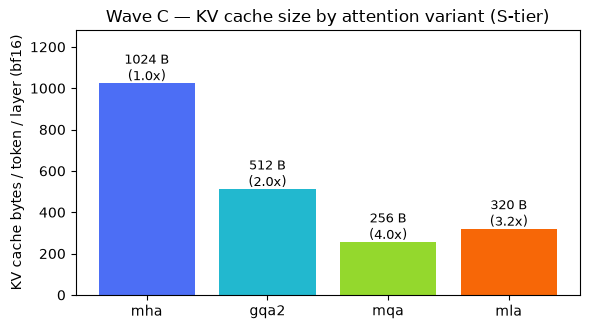

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.4))
colors = {"mha":"#4C6EF5","gqa2":"#22B8CF","mqa":"#94D82D","mla":"#F76707"}
ax.bar(df.index, df["bytes_tok_layer"], color=[colors[v] for v in df.index])
for i, v in enumerate(df["bytes_tok_layer"]):
    ax.text(i, v + 15, f"{v} B\n({df['x_smaller_than_MHA'].iloc[i]}x)", ha="center", fontsize=9)
ax.set_ylabel("KV cache bytes / token / layer (bf16)")
ax.set_title("Wave C — KV cache size by attention variant (S-tier)")
ax.set_ylim(0, df["bytes_tok_layer"].max() * 1.25)
plt.tight_layout(); plt.show()


## 4. The catch: cache size ↓ but decode *compute* ↑ (and what we didn't implement)

Our `MLAAttention` re-expands `k_nope` and `v` from the cached latent **every decode step** via
`W_UKV` (a `kv_lora_rank → n_heads*(nope+v)` matmul). So MLA does *more* FLOPs per token than MHA,
which just reads K/V from the cache. Wave C's bench measured MLA decoding ~25% slower per token
than MHA at S-tier — an honest trade: **you buy cache memory with compute.**

Two production optimizations we deliberately skipped (out of scope; note them for the writeup):

- **Weight absorption.** $q^{C\top} k^{C} = (W_{UQ}c_q)^\top (W_{UK} c_{kv})
  = c_q^\top (W_{UQ}^\top W_{UK}) c_{kv}$ — the two up-projections can be folded (absorbed) into a
  single matrix acting directly on the latents, so you never materialize per-head K at decode.
  That removes most of MLA's extra decode compute. It's an inference-time algebra trick, not a
  different model.
- **Pre-allocated cache.** Our cache uses `torch.cat` each step → $O(T)$ copy per step, $O(T^2)$
  total. Real serving pre-allocates the cache to max length and writes in place.

At our tiny 10M-param scale, single-stream decode is *launch-overhead bound* anyway, so neither
the cache nor MLA changes wall-clock much — the cache's payoff is **memory** (→ larger batch /
longer context), which is unconditional and is exactly what the bytes/token table shows.


In [5]:
# Sanity: cached decode reproduces the full-sequence forward bit-for-bit (up to fp error).
cfg_mla = ModelConfig.from_yaml("../configs/model_s_attn_mla.yaml")
gpt = GPT(cfg_mla).eval()
x = torch.randint(0, cfg_mla.vocab_size, (1, 24))
with torch.no_grad():
    full, _ = gpt(x)
    caches = [make_cache(cfg_mla) for _ in range(cfg_mla.n_layers)]
    outs = [gpt(x[:, :8], caches=caches)[0]]
    for t in range(8, 24):
        outs.append(gpt(x[:, t:t+1], caches=caches)[0])
    inc = torch.cat(outs, dim=1)
print("max |full - cached decode| =", (full - inc).abs().max().item(), "(≈ fp32 round-off)")


max |full - cached decode| = 8.940696716308594e-07 (≈ fp32 round-off)


## 5. Recap

- **MHA** caches full per-head K & V → biggest cache, most expressive.
- **GQA/MQA** cache *fewer* K/V heads → smaller cache, less head diversity.
- **MLA** caches a *compressed latent* + one shared RoPE key, rebuilding full per-head K/V →
  near-MQA cache with near-MHA expressiveness, paid for with extra decode compute (absorbable).
- The **decoupled RoPE** split (content vs rope) is what lets the cached latent stay
  position-free and therefore compressible.

See `docs/results/ablation_log.md` (Wave C) for whether MLA held quality against the MHA control
at equal tokens, and `docs/results/wave_c_inference_bench.csv` for the measured bytes & tok/s.
